# K-Means Clustering Data Polutan Udara


## 1. Python

Alur pengolahan data pada bagian Python adalah sebagai berikut.

1. **Ambil data.** Dua tabel fitur TSFEL (skenario interpolasi linear dan polinomial) dibaca dari database MySQL.
2. **Pisahkan fitur.** Kolom `id`, `nama`, dan `daerah` dipisahkan dari 204 kolom fitur numerik.
3. **Standardisasi.** Fitur distandardisasi dengan `StandardScaler` (Z-Score) agar setiap fitur memiliki skala yang sebanding.
4. **Reduksi dimensi.** Dibuat empat kondisi, yaitu 204 fitur asli, lalu 203, 74, dan 37 fitur memakai `FeatureAgglomeration` (metode Ward).
5. **K-Means.** Untuk tiap kondisi, K-Means diuji pada K = 2 sampai 10, dengan Silhouette Score dan inertia (Elbow) sebagai pembanding.
6. **Hasil.** K final mengikuti Silhouette Score, lalu anggota tiap cluster ditampilkan dalam tabel dan dipetakan berdasarkan koordinat daerah.

Seluruh proses dijalankan untuk dua skenario dan empat kondisi dimensi, sehingga menghasilkan delapan kombinasi hasil.

### 1.1 Library dan Koneksi Database

Bagian ini menyiapkan seluruh pustaka yang dipakai sepanjang notebook, sekaligus membuka koneksi ke database MySQL tempat dua tabel fitur (skenario linear dan polinomial) disimpan. Koneksi ini dipakai ulang di seluruh sel berikutnya, jadi cukup dijalankan sekali di awal.

In [1]:
!pip install pymysql sqlalchemy geopy folium -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DB_HOST = "basisdata2-c.my.id"
DB_PORT = 3306
DB_NAME = "basisda1_PSD-A-Interpolasi"
DB_USER = "basisda1_PSD-User"
DB_PASS = "PSD-A#2026"

# Password mengandung karakter "#", sehingga perlu di-encode dengan quote_plus
# sebelum disisipkan ke URL koneksi.
db_url = (
    f"mysql+pymysql://{DB_USER}:{quote_plus(DB_PASS)}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
engine = create_engine(db_url)

# K-Means diuji untuk k = 2 sampai 10.
K_RANGE = range(2, 11)

RANDOM_STATE = 42
N_INIT = 10
MAX_ITER = 300


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00


**Penjelasan kode:**

1. Koneksi database dibuat memakai `SQLAlchemy` dengan driver `pymysql`, karena databasenya bertipe MySQL.
2. `quote_plus()` dipakai khusus untuk password, supaya karakter `#` di dalamnya tidak mengacaukan struktur URL koneksi.
3. `K_RANGE` menetapkan rentang jumlah cluster yang akan diuji di sepanjang notebook, dari 2 sampai 10, sesuai permintaan tugas.


### 1.2 Memuat Data Dua Skenario Interpolasi


In [2]:
TABEL = {
    "linear": "ekstraksi_fitur_linear",
    "polynomial": "ekstraksi_fitur_polynomial",
}

data_mentah = {}
for skenario, nama_tabel in TABEL.items():
    with engine.connect() as conn:
        df = pd.read_sql(text(f"SELECT * FROM `{nama_tabel}` ORDER BY id;"), conn)
    data_mentah[skenario] = df
    print(f"Skenario {skenario}: {df.shape[0]} baris, {df.shape[1]} kolom")

    print(f"Nilai kosong: {int(df.isna().sum().sum())}")
    display(df.iloc[:, :8].head(10))
    print()

Skenario linear: 37 baris, 207 kolom
Nilai kosong: 0


,id,nama,daerah,no2_abs_energy,no2_auc,no2_autocorr,no2_average_power,no2_calc_centroid
0,1,Muhammad Ali Murtadho,Baron Nganjuk,3.327524e-07,0.010370,17.0,9.116503e-10,203.671392
1,2,Ainur Raftuzzaki,Nunukan,1.562548e-08,0.001696,3.0,6.510616e-11,124.455523
2,4,M. Hendrik Purwanto,"Sreseh, Sampang",2.437783e-07,0.008625,9.0,6.752861e-10,163.948262
3,6,Okan Syailendra wahyudi,"Manyar, Gresik",2.219284e-06,0.025450,6.0,6.096933e-09,192.029475
4,10,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",4.397654e-06,0.048498,2.0,7.569111e-09,325.789743
5,11,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,3.702058e-07,0.010905,8.0,1.014262e-09,194.285209
6,12,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",1.523980e-06,0.022417,3.0,4.175288e-09,184.039735
7,13,Rian Renaldy,"Waru, Pamekasan",1.123197e-07,0.005901,5.0,3.077253e-10,168.844890
8,14,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",3.246208e-07,0.010392,3.0,8.893721e-10,199.381425
9,15,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",3.478568e-07,0.010814,3.0,9.530324e-10,170.541601



Skenario polynomial: 37 baris, 207 kolom
Nilai kosong: 0


,id,nama,daerah,no2_abs_energy,no2_auc,no2_autocorr,no2_average_power,no2_calc_centroid
0,1,Muhammad Ali Murtadho,Baron Nganjuk,3.327524e-07,0.010370,17.0,9.116503e-10,203.671392
1,2,Ainur Raftuzzaki,Nunukan,1.718086e-08,0.001736,2.0,7.158691e-11,124.290205
2,4,M. Hendrik Purwanto,"Sreseh, Sampang",3.913332e-07,0.009838,12.0,1.084025e-09,130.808445
3,6,Okan Syailendra wahyudi,"Manyar, Gresik",2.432000e-06,0.026015,6.0,6.681318e-09,196.790603
4,9,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",4.409992e-06,0.048503,2.0,7.590347e-09,325.271345
5,10,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,3.953901e-07,0.010989,7.0,1.083260e-09,189.512314
6,11,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",1.785530e-06,0.023521,3.0,4.891864e-09,173.330768
7,12,Rian Renaldy,"Waru, Pamekasan",1.326685e-07,0.006070,4.0,3.634754e-10,160.174724
8,13,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",3.299169e-07,0.010448,3.0,9.038819e-10,200.719390
9,14,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",3.478568e-07,0.010814,3.0,9.530324e-10,170.541601


**Penjelasan kode:** kedua tabel dimuat ke dalam satu dictionary `data_mentah`, dengan kunci nama skenarionya, supaya proses selanjutnya bisa diulang dengan cara yang sama untuk kedua skenario sekaligus, tanpa menulis kode dua kali secara terpisah.


### 1.3 Pemisahan Kolom Identitas dan Kolom Fitur


Tiap tabel punya tiga kolom identitas, yaitu `id`, `nama`, dan `daerah`, yang bukan bagian dari fitur polutan dan tidak diikutsertakan dalam perhitungan jarak antar data saat klustering. Sisanya, 204 kolom, adalah fitur numerik hasil ekstraksi TSFEL untuk tiga polutan.


In [3]:
KOLOM_IDENTITAS = ["id", "nama", "daerah"]

info_skenario = {}
for skenario, df in data_mentah.items():
    kolom_fitur = [c for c in df.columns if c not in KOLOM_IDENTITAS]
    X_mentah = df[kolom_fitur].apply(pd.to_numeric, errors="coerce")

    info_skenario[skenario] = {
        "df": df,
        "kolom_fitur": kolom_fitur,
        "X_mentah": X_mentah,
    }
    print(f"Skenario {skenario}: {len(kolom_fitur)} kolom fitur, "
          f"{X_mentah.isna().sum().sum()} nilai kosong terdeteksi")


Skenario linear: 204 kolom fitur, 0 nilai kosong terdeteksi
Skenario polynomial: 204 kolom fitur, 0 nilai kosong terdeteksi


**Penjelasan kode:** `pd.to_numeric(errors="coerce")` memaksa setiap kolom fitur menjadi angka, dan mengubah nilai yang tidak terbaca sebagai angka menjadi kosong (`NaN`), supaya ketahuan lebih dulu kalau ada kolom yang bermasalah sebelum masuk ke tahap standardisasi.


### 1.4 Fungsi Evaluasi K-Means, Silhouette, dan Elbow


In [4]:
def evaluasi_kmeans(X, k_range=K_RANGE):
    hasil = []

    for k in k_range:
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=N_INIT,
            max_iter=MAX_ITER
        )
        label = model.fit_predict(X)

        hasil.append({
            "k": k,
            "silhouette": silhouette_score(X, label),
            "inertia": model.inertia_
        })

    return pd.DataFrame(hasil)


def k_terbaik_silhouette(tabel_k):
    baris = tabel_k.loc[tabel_k["silhouette"].idxmax()]
    return int(baris["k"]), float(baris["silhouette"])


# Dari grafik Elbow pada data ini, titik elbow dibaca pada K = 4.
# Nilai inertia tetap dihitung dan grafik tetap ditampilkan agar keputusan dapat dilihat.
K_ELBOW = 4

def k_terbaik_elbow(tabel_k):
    return K_ELBOW


**Penjelasan kode:** `evaluasi_kmeans()` mencoba setiap nilai k dari 2 sampai 10, menjalankan K-Means untuk tiap k, lalu menghitung silhouette score-nya. Semakin tinggi silhouette score, semakin jelas pemisahan antar cluster yang terbentuk. `k_terbaik_dari_tabel()` mengambil baris dengan silhouette tertinggi dari tabel itu.


### 1.5 Reduksi Dimensi 203, 74, dan 37 Fitur


Tahap analisis menggunakan empat kondisi, tanpa reduksi (204 fitur asli), lalu reduksi ke 203, 74, dan 37 fitur.

PCA, cara reduksi dimensi yang paling umum dipakai, punya batas matematis, jumlah komponen yang bisa dihasilkan tidak boleh melebihi jumlah baris data (`min(jumlah_sampel, jumlah_fitur)`). Karena jumlah daerah yang terkumpul di database masih di bawah 203, PCA akan gagal dijalankan untuk target 203 maupun 74. Karena itu, dipakai `FeatureAgglomeration` sebagai gantinya untuk ketiga tahap reduksi tersebut.

**Konsep `FeatureAgglomeration`, dibandingkan PCA:**

PCA mengelompokkan baris data, mencari kombinasi dari seluruh kolom yang paling banyak menangkap variasi antar baris, sehingga jumlah komponennya dibatasi jumlah baris.

`FeatureAgglomeration` justru mengelompokkan kolom (fitur), bukan baris. Cara kerjanya mirip hierarchical clustering yang biasa dipakai untuk mengelompokkan data, cuma di sini diterapkan ke kolom, bukan ke baris.

1. Dihitung seberapa mirip tiap pasang kolom (jarak Euclidean antar kolom, tiap kolom dianggap satu titik di ruang berdimensi jumlah baris).
2. Dimulai dari 204 kolom terpisah, dua kolom paling mirip digabung jadi satu kelompok.
3. Langkah ini diulang, tiap kali menggabung dua kelompok paling mirip, sampai jumlah kelompok yang tersisa sesuai target (misalnya 37).
4. Tiap kelompok akhirnya diwakili satu nilai, yaitu rata-rata dari semua kolom anggotanya.

Karena yang dikelompokkan itu kolom, bukan baris, jumlah kelompok yang diminta sama sekali tidak dibatasi oleh jumlah baris data, sehingga target 203, 74, dan 37 bisa selalu dicapai persis, berapa pun jumlah daerah yang ada di database saat ini.

Konsekuensinya, kolom hasil `FeatureAgglomeration` adalah gabungan beberapa fitur asli (tidak lagi bisa disebut nama fitur aslinya satu per satu), dan tidak ada ukuran "persentase variasi yang masih terjaga" sejelas `explained_variance_ratio_` pada PCA.

In [5]:
from sklearn.cluster import FeatureAgglomeration

TAHAP_REDUKSI = [None, 203, 74, 37]

def reduksi_dimensi(X_scaled, n_target):
    if n_target is None:
        return X_scaled, X_scaled.shape[1], None

    reducer = FeatureAgglomeration(
        n_clusters=n_target,
        linkage="ward"
    )

    X_reduksi = reducer.fit_transform(X_scaled)

    return X_reduksi, X_reduksi.shape[1], reducer


**Penjelasan kode:** parameter `linkage="ward"` menentukan aturan untuk menilai "seberapa mirip dua kelompok kolom" setiap kali digabung, metode Ward dipilih karena cenderung menghasilkan kelompok berukuran seimbang, bukan satu kelompok besar dan sisanya kecil-kecil. `n_clusters=n_target` memastikan jumlah kolom akhir tepat sesuai target (203, 74, atau 37). Kondisi tanpa reduksi tetap memakai 204 fitur asli, tidak melewati `FeatureAgglomeration` sama sekali.

### 1.6 Eksperimen Tanpa Reduksi dan Dengan Reduksi Dimensi


In [6]:
hasil_eksperimen = {}
ringkasan_list = []

for skenario, info in info_skenario.items():
    df = info["df"]
    X_mentah = info["X_mentah"]

    baris_valid = X_mentah.dropna().index
    df_valid = df.loc[baris_valid].reset_index(drop=True)
    X_valid = X_mentah.loc[baris_valid].reset_index(drop=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_valid)

    for dimensi_diminta in TAHAP_REDUKSI:
        dimensi = X_scaled.shape[1] if dimensi_diminta is None else dimensi_diminta

        X_tahap, dimensi_efektif, reducer = reduksi_dimensi(
            X_scaled, dimensi_diminta
        )

        tabel_k = evaluasi_kmeans(X_tahap)
        k_silhouette, silhouette_terbaik = k_terbaik_silhouette(tabel_k)
        k_elbow = k_terbaik_elbow(tabel_k)

        # K final mengikuti Silhouette Score.
        model_final = KMeans(
            n_clusters=k_silhouette,
            random_state=RANDOM_STATE,
            n_init=N_INIT,
            max_iter=MAX_ITER
        )
        label_cluster = model_final.fit_predict(X_tahap)

        df_hasil = df_valid[["nama", "daerah"]].copy()
        df_hasil["cluster"] = label_cluster

        kunci = (skenario, dimensi)

        hasil_eksperimen[kunci] = {
            "dimensi_efektif": dimensi_efektif,
            "tabel_k": tabel_k,
            "k_silhouette": k_silhouette,
            "k_elbow": k_elbow,
            "k_terbaik": k_silhouette,
            "silhouette_terbaik": silhouette_terbaik,
            "df_hasil": df_hasil,
            "X_tahap": X_tahap,
            "model_final": model_final,
            "reducer": reducer
        }

        ringkasan_list.append({
            "skenario": skenario,
            "dimensi": dimensi,
            "dimensi_efektif": dimensi_efektif,
            "k_silhouette": k_silhouette,
            "k_elbow": k_elbow,
            "k_terbaik": k_silhouette,
            "silhouette_terbaik": round(silhouette_terbaik, 4),
            "inertia_k_terbaik": round(model_final.inertia_, 4)
        })

        print(
            f"{skenario} | {dimensi} fitur | "
            f"K Silhouette={k_silhouette} | "
            f"K Elbow={k_elbow} | "
            f"K final={k_silhouette} | "
            f"Silhouette={silhouette_terbaik:.4f}"
        )


linear | 204 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.4909
linear | 203 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.4909
linear | 74 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.4333
linear | 37 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.4317
polynomial | 204 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.5375
polynomial | 203 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.5375
polynomial | 74 fitur | K Silhouette=2 | K Elbow=4 | K final=2 | Silhouette=0.4959
polynomial | 37 fitur | K Silhouette=3 | K Elbow=4 | K final=3 | Silhouette=0.5248


**Penjelasan kode:**

Setiap skenario diuji pada empat kondisi, yaitu tanpa reduksi 204 fitur, reduksi 203 fitur, reduksi 74 fitur, dan reduksi 37 fitur. Untuk setiap kondisi, K-Means diuji pada K = 2 sampai 10. Silhouette Score digunakan untuk mencari K dengan nilai tertinggi. Inertia digunakan untuk membuat grafik Elbow. Pada data ini, titik Elbow dibaca pada K = 4. K final mengikuti hasil Silhouette.


### 1.7 Penentuan K Terbaik

Bagian ini merangkum hasil dari percobaan sebelumnya (bagian 1.6) ke dalam satu tabel ringkas, menunjukkan berapa K yang dipilih lewat Silhouette Score dan berapa K yang dibaca lewat metode Elbow, untuk tiap kombinasi skenario dan tahap dimensi.

In [7]:
ringkasan = pd.DataFrame(ringkasan_list)

ringkasan_terurut = (
    ringkasan
    .sort_values("silhouette_terbaik", ascending=False)
    .reset_index(drop=True)
)

display(ringkasan_terurut)


,skenario,dimensi,dimensi_efektif,k_silhouette,k_elbow,k_terbaik,silhouette_terbaik,inertia_k_terbaik
0,polynomial,203,203,2,4,2,0.5375,5450.8166
1,polynomial,204,204,2,4,2,0.5375,5450.8166
2,polynomial,37,37,3,4,3,0.5248,708.5529
3,polynomial,74,74,2,4,2,0.4959,1990.6720
4,linear,203,203,2,4,2,0.4909,5442.2698
5,linear,204,204,2,4,2,0.4909,5442.2698
6,linear,74,74,2,4,2,0.4333,2050.0806
7,linear,37,37,2,4,2,0.4317,877.6405


**Penjelasan kode:** tabel menunjukkan K terbaik berdasarkan Silhouette dan K berdasarkan Elbow. Pada data ini, hasil Elbow dibaca pada K = 4. K final mengikuti Silhouette Score.


#### 1.7.1 Grafik Silhouette dan Elbow


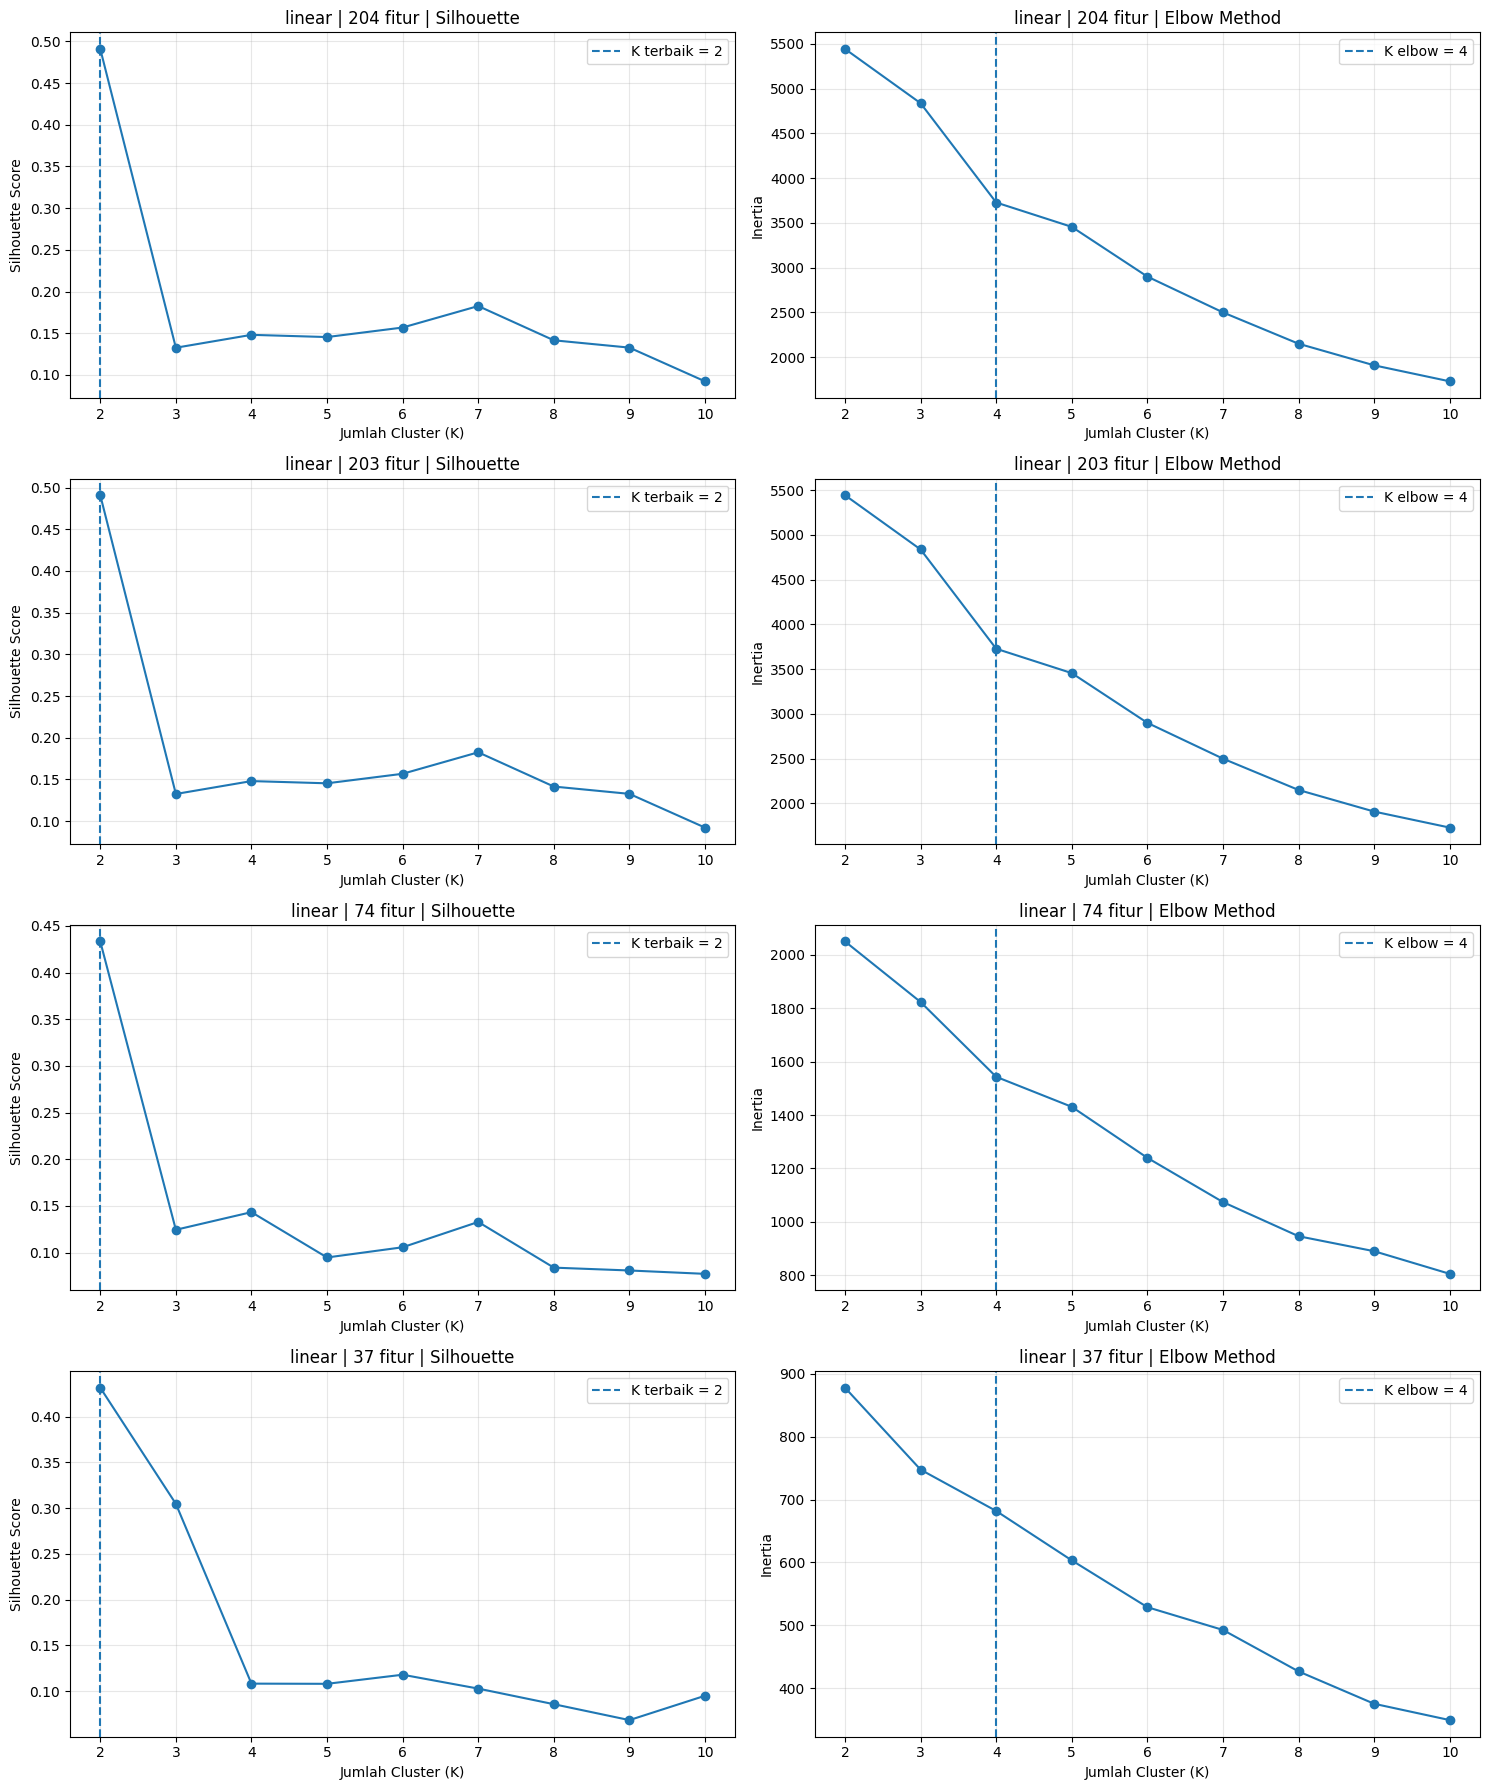

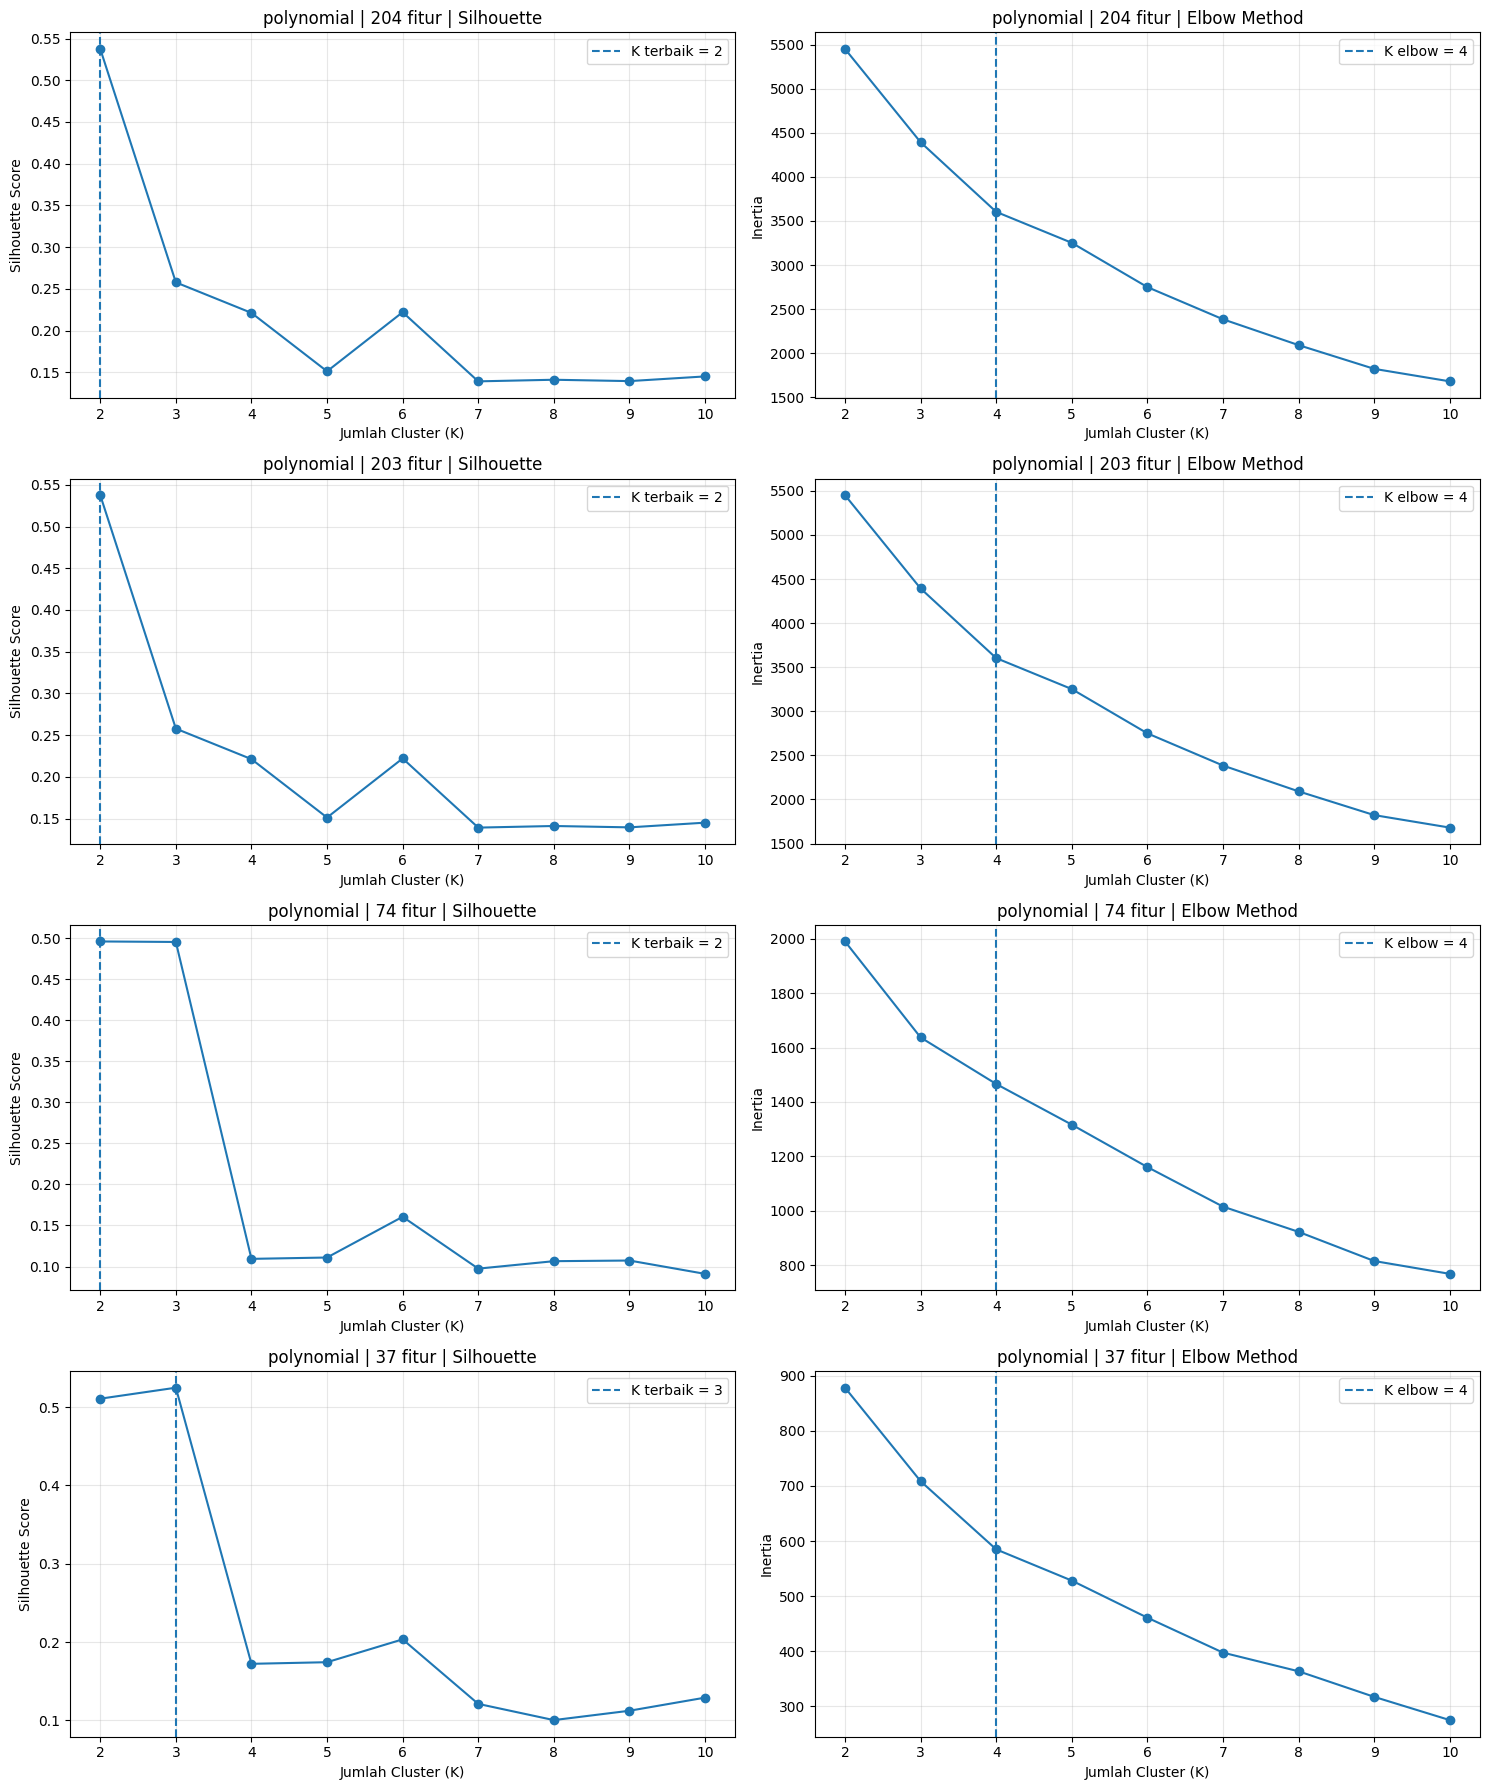

In [8]:
for skenario in TABEL.keys():
    dimensi_list = [204, 203, 74, 37]

    fig, axes = plt.subplots(
        4, 2,
        figsize=(15, 18)
    )

    for i, dimensi in enumerate(dimensi_list):
        hasil = hasil_eksperimen[(skenario, dimensi)]
        tabel_k = hasil["tabel_k"]

        axes[i, 0].plot(
            tabel_k["k"],
            tabel_k["silhouette"],
            marker="o"
        )
        axes[i, 0].axvline(
            hasil["k_silhouette"],
            linestyle="--",
            label=f"K terbaik = {hasil['k_silhouette']}"
        )
        axes[i, 0].set_title(
            f"{skenario} | {dimensi} fitur | Silhouette"
        )
        axes[i, 0].set_xlabel("Jumlah Cluster (K)")
        axes[i, 0].set_ylabel("Silhouette Score")
        axes[i, 0].set_xticks(list(K_RANGE))
        axes[i, 0].grid(alpha=0.3)
        axes[i, 0].legend()

        axes[i, 1].plot(
            tabel_k["k"],
            tabel_k["inertia"],
            marker="o"
        )
        axes[i, 1].axvline(
            hasil["k_elbow"],
            linestyle="--",
            label=f"K elbow = {hasil['k_elbow']}"
        )
        axes[i, 1].set_title(
            f"{skenario} | {dimensi} fitur | Elbow Method"
        )
        axes[i, 1].set_xlabel("Jumlah Cluster (K)")
        axes[i, 1].set_ylabel("Inertia")
        axes[i, 1].set_xticks(list(K_RANGE))
        axes[i, 1].grid(alpha=0.3)
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()


**Penjelasan kode:** grafik kiri menunjukkan Silhouette Score untuk K = 2 sampai 10. Nilai tertinggi menjadi K terbaik menurut Silhouette. Grafik kanan menunjukkan inertia. Titik elbow dibaca dari grafik pada K = 4.


### 1.8 Perbandingan K Terbaik

Tabel ringkasan dari bagian 1.7 ditampilkan terpisah per skenario, supaya pola perubahan K dan silhouette antar tahap dimensi (204, 203, 74, 37) lebih mudah dibaca berurutan dari kiri ke kanan.

In [9]:
for skenario in TABEL.keys():
    subset = (
        ringkasan[ringkasan["skenario"] == skenario]
        .sort_values("dimensi", ascending=False)
    )

    display(
        subset[
            [
                "skenario",
                "dimensi",
                "dimensi_efektif",
                "k_silhouette",
                "k_elbow",
                "k_terbaik",
                "silhouette_terbaik"
            ]
        ]
    )


,skenario,dimensi,dimensi_efektif,k_silhouette,k_elbow,k_terbaik,silhouette_terbaik
0,linear,204,204,2,4,2,0.4909
1,linear,203,203,2,4,2,0.4909
2,linear,74,74,2,4,2,0.4333
3,linear,37,37,2,4,2,0.4317


,skenario,dimensi,dimensi_efektif,k_silhouette,k_elbow,k_terbaik,silhouette_terbaik
4,polynomial,204,204,2,4,2,0.5375
5,polynomial,203,203,2,4,2,0.5375
6,polynomial,74,74,2,4,2,0.4959
7,polynomial,37,37,3,4,3,0.5248


**Penjelasan kode:** tabel ini memperlihatkan perbedaan hasil penentuan k pada setiap tahap. `dimensi_diminta` menunjukkan target PCA, sedangkan `dimensi_efektif` menunjukkan jumlah komponen yang benar-benar digunakan. Ini penting untuk menunjukkan bahwa target 203 dan 74 tidak dapat dicapai apabila jumlah daerah masih hanya 37.


### 1.9 Distribusi Anggota Cluster

Sebelum masuk ke pemilihan hasil akhir, bagian ini mengecek dulu apakah pembagian cluster di tiap kombinasi masuk akal, dengan melihat berapa banyak daerah yang masuk ke tiap cluster. Cluster yang anggotanya cuma satu atau dua daerah perlu dicurigai sebagai outlier, bukan pengelompokan yang bermakna.

In [10]:
for (skenario, dimensi), hasil in hasil_eksperimen.items():
    print(
        f"\nSkenario {skenario}, dimensi {dimensi} "
        f"(K final={hasil['k_terbaik']}, "
        f"K silhouette={hasil['k_silhouette']}, "
        f"K elbow={hasil['k_elbow']}, "
        f"silhouette={hasil['silhouette_terbaik']:.4f})"
    )

    distribusi = (
        hasil["df_hasil"]["cluster"]
        .value_counts()
        .sort_index()
    )

    display(
        distribusi.rename("jumlah_anggota")
    )



Skenario linear, dimensi 204 (K final=2, K silhouette=2, K elbow=4, silhouette=0.4909)


,jumlah_anggota
cluster,
0,34
1,3



Skenario linear, dimensi 203 (K final=2, K silhouette=2, K elbow=4, silhouette=0.4909)


,jumlah_anggota
cluster,
0,34
1,3



Skenario linear, dimensi 74 (K final=2, K silhouette=2, K elbow=4, silhouette=0.4333)


...

,jumlah_anggota
cluster,
0,35
1,2



Skenario polynomial, dimensi 74 (K final=2, K silhouette=2, K elbow=4, silhouette=0.4959)


,jumlah_anggota
cluster,
0,35
1,2



Skenario polynomial, dimensi 37 (K final=3, K silhouette=3, K elbow=4, silhouette=0.5248)


,jumlah_anggota
cluster,
0,35
1,1
2,1


**Penjelasan kode:** untuk setiap kombinasi skenario dan dimensi, kolom `cluster` pada tabel hasil dihitung dengan `value_counts()`, sehingga terlihat berapa daerah yang masuk ke tiap cluster. Cluster yang hanya berisi satu atau dua daerah ditandai sebagai kandidat outlier. Pada data ini hasilnya konsisten, yaitu satu cluster besar (34-35 daerah) dan satu cluster kecil (2-3 daerah), kecuali Polynomial 37 fitur yang memakai K = 3 (35, 1, dan 1 daerah).

### 1.10 Hasil Klustering untuk Seluruh Delapan Kombinasi

Ada delapan kombinasi yang sudah diuji di bagian 1.6, yaitu dua skenario (linear, polinomial) dikalikan empat tahap dimensi (204 fitur asli, 203, 74, dan 37). Bagian ini menampilkan hasil akhir kedelapannya satu per satu secara eksplisit, bukan cuma satu kombinasi yang dianggap "terbaik", supaya seluruh kombinasi tetap bisa dibandingkan dan dilaporkan.

In [11]:
DIMENSI_URUT = [204, 203, 74, 37]

hasil_per_kombinasi = {}

for skenario in TABEL.keys():
    for dimensi in DIMENSI_URUT:
        hasil = hasil_eksperimen[(skenario, dimensi)]
        hasil_per_kombinasi[(skenario, dimensi)] = hasil["df_hasil"].copy()

        print(
            f"=== Skenario: {skenario} | Dimensi diminta: {dimensi} | "
            f"Dimensi efektif: {hasil['dimensi_efektif']} ==="
        )
        print(
            f"K Silhouette = {hasil['k_silhouette']} | "
            f"K Elbow = {hasil['k_elbow']} | "
            f"K final dipakai = {hasil['k_terbaik']} | "
            f"Silhouette = {hasil['silhouette_terbaik']:.4f}"
        )
        display(hasil["df_hasil"])
        print()


=== Skenario: linear | Dimensi diminta: 204 | Dimensi efektif: 204 ===
K Silhouette = 2 | K Elbow = 4 | K final dipakai = 2 | Silhouette = 0.4909


,nama,daerah,cluster
0,Muhammad Ali Murtadho,Baron Nganjuk,0
1,Ainur Raftuzzaki,Nunukan,0
2,M. Hendrik Purwanto,"Sreseh, Sampang",0
3,Okan Syailendra wahyudi,"Manyar, Gresik",0
4,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0
5,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
6,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
7,Rian Renaldy,"Waru, Pamekasan",0
8,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0
9,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0



=== Skenario: linear | Dimensi diminta: 203 | Dimensi efektif: 203 ===
K Silhouette = 2 | K Elbow = 4 | K final dipakai = 2 | Silhouette = 0.4909


,nama,daerah,cluster
0,Muhammad Ali Murtadho,Baron Nganjuk,0
1,Ainur Raftuzzaki,Nunukan,0
2,M. Hendrik Purwanto,"Sreseh, Sampang",0
3,Okan Syailendra wahyudi,"Manyar, Gresik",0
4,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0
5,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
6,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
7,Rian Renaldy,"Waru, Pamekasan",0
8,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0
9,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0



=== Skenario: linear | Dimensi diminta: 74 | Dimensi efektif: 74 ===
K Silhouette = 2 | K Elbow = 4 | K final dipakai = 2 | Silhouette = 0.4333


...

,nama,daerah,cluster
0,Muhammad Ali Murtadho,Baron Nganjuk,0
1,Ainur Raftuzzaki,Nunukan,0
2,M. Hendrik Purwanto,"Sreseh, Sampang",0
3,Okan Syailendra wahyudi,"Manyar, Gresik",0
4,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0
5,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
6,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
7,Rian Renaldy,"Waru, Pamekasan",0
8,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0
9,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0



=== Skenario: polynomial | Dimensi diminta: 74 | Dimensi efektif: 74 ===
K Silhouette = 2 | K Elbow = 4 | K final dipakai = 2 | Silhouette = 0.4959


,nama,daerah,cluster
0,Muhammad Ali Murtadho,Baron Nganjuk,0
1,Ainur Raftuzzaki,Nunukan,0
2,M. Hendrik Purwanto,"Sreseh, Sampang",0
3,Okan Syailendra wahyudi,"Manyar, Gresik",0
4,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",0
5,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
6,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
7,Rian Renaldy,"Waru, Pamekasan",0
8,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0
9,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0



=== Skenario: polynomial | Dimensi diminta: 37 | Dimensi efektif: 37 ===
K Silhouette = 3 | K Elbow = 4 | K final dipakai = 3 | Silhouette = 0.5248


,nama,daerah,cluster
0,Muhammad Ali Murtadho,Baron Nganjuk,0
1,Ainur Raftuzzaki,Nunukan,0
2,M. Hendrik Purwanto,"Sreseh, Sampang",0
3,Okan Syailendra wahyudi,"Manyar, Gresik",0
4,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",2
5,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0
6,Ahmad Syahrul Farihin,"Gresik Kota, Gresik",0
7,Rian Renaldy,"Waru, Pamekasan",0
8,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0
9,AHMAD MAULANA ISHAQ,"Kertosono, Nganjuk",0


**Penjelasan kode:** hasil klustering tiap kombinasi disalin ke dictionary `hasil_per_kombinasi` dengan kunci `(skenario, dimensi)`, lalu ditampilkan satu per satu bersama K Silhouette, K Elbow, K final, dan nilai Silhouette-nya. Dictionary ini dipakai ulang pada bagian pemetaan, sehingga hasil klustering tidak perlu dihitung ulang.

Label cluster (0, 1, 2) hanya penanda dan tidak punya arti urutan. Karena itu, hasil antar kombinasi dibandingkan lewat siapa saja anggota tiap cluster, bukan lewat angka labelnya. Contohnya pada Linear 74 fitur, cluster kecil berlabel 0, sedangkan pada dimensi lain berlabel 1, padahal anggotanya sama.

### 1.11 Mengambil Koordinat Tiap Daerah

Nama daerah yang sama persis muncul di kedelapan kombinasi (karena daerahnya sama, cuma pengelompokan cluster-nya yang beda), jadi koordinat tiap daerah cukup dicari satu kali saja di sini, lalu dipakai ulang untuk memetakan seluruh delapan hasil pada bagian 1.12.

In [12]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import requests
import time

geolocator = Nominatim(user_agent="klustering_polutan_indonesia")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

KOREKSI_DAERAH = {
    "Bandung - Jogoroto, Jombang": "Jogoroto, Jombang",
    "Banyu Ajuh, Perumnas, Kamal": "Kamal, Bangkalan",
    "Kec. Kalianget, Sumenep": "Kalianget, Sumenep",
}

def cari_koordinat(nama_daerah):
    nama = KOREKSI_DAERAH.get(nama_daerah, nama_daerah)

    hasil = geocode(f"{nama}, Indonesia")
    if hasil is not None:
        return hasil.latitude, hasil.longitude

    try:
        r = requests.get(
            "https://photon.komoot.io/api/",
            params={"q": f"{nama}, Indonesia", "limit": 1},
            timeout=10,
        )
        fitur = r.json().get("features", [])
        if fitur:
            lon, lat = fitur[0]["geometry"]["coordinates"]
            return lat, lon
    except Exception:
        pass

    return None, None


# Gabungan nama daerah dari semua kombinasi, supaya tiap nama cuma dicari sekali
semua_daerah = set()
for df_hasil in hasil_per_kombinasi.values():
    semua_daerah.update(df_hasil["daerah"].unique())

koordinat = {}
daerah_gagal = []
for nama_daerah in semua_daerah:
    lat, lon = cari_koordinat(nama_daerah)
    koordinat[nama_daerah] = (lat, lon)
    if lat is None:
        daerah_gagal.append(nama_daerah)
    time.sleep(1)

koordinat_daerah = pd.DataFrame(
    [{"daerah": d, "lat": lat, "lon": lon} for d, (lat, lon) in koordinat.items()]
)

print(f"Berhasil dapat koordinat: {len(semua_daerah) - len(daerah_gagal)} dari {len(semua_daerah)} daerah")
if daerah_gagal:
    print("Daerah yang masih gagal:")
    for d in daerah_gagal:
        print(f"  - {d}")


Berhasil dapat koordinat: 36 dari 36 daerah


**Penjelasan kode:** fungsi `cari_koordinat()` mencari latitude dan longitude tiap daerah. Pencarian pertama memakai `Nominatim` (OpenStreetMap) dengan jeda satu detik per permintaan sesuai aturan layanannya. Jika tidak ditemukan, dipakai layanan cadangan `photon.komoot.io`. Kamus `KOREKSI_DAERAH` memperbaiki penulisan daerah yang tidak baku (misalnya "Banyu Ajuh, Perumnas, Kamal" diganti "Kamal, Bangkalan") sebelum dicari. Nama daerah dikumpulkan dalam `set` agar tiap nama hanya dicari sekali, lalu hasilnya disimpan dalam tabel `koordinat_daerah`.

### 1.12 Visualisasi Hasil Klustering pada Peta Satelit, Seluruh Delapan Kombinasi

Delapan peta ditampilkan berurutan sesuai `DIMENSI_URUT`, satu peta untuk tiap kombinasi skenario dan tahap dimensi, supaya pola pengelompokan di tiap tahap bisa dibandingkan langsung, termasuk melihat apakah pengelompokannya berubah banyak atau tetap mirip begitu dimensinya direduksi.

In [13]:
import folium
from IPython.display import display as tampilkan

WARNA = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "cadetblue", "darkgreen", "pink", "black",
]

for skenario in TABEL.keys():
    for dimensi in DIMENSI_URUT:
        hasil = hasil_eksperimen[(skenario, dimensi)]
        df_hasil = hasil_per_kombinasi[(skenario, dimensi)]

        data_peta = df_hasil.merge(koordinat_daerah, on="daerah", how="left")
        data_peta = data_peta.dropna(subset=["lat", "lon"])

        print(
            f"=== Skenario: {skenario} | Dimensi: {dimensi} | "
            f"K final = {hasil['k_terbaik']} | Silhouette = {hasil['silhouette_terbaik']:.4f} ==="
        )

        if len(data_peta) == 0:
            print("Tidak ada koordinat yang berhasil ditemukan untuk kombinasi ini.")
            continue

        pusat_lat = data_peta["lat"].mean()
        pusat_lon = data_peta["lon"].mean()

        peta = folium.Map(
            location=[pusat_lat, pusat_lon],
            zoom_start=6,
            tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
            attr="Esri World Imagery",
        )

        warna_cluster = {
            c: WARNA[i % len(WARNA)]
            for i, c in enumerate(sorted(data_peta["cluster"].unique()))
        }

        for _, baris in data_peta.iterrows():
            folium.CircleMarker(
                location=[baris["lat"], baris["lon"]],
                radius=7,
                color=warna_cluster[baris["cluster"]],
                fill=True,
                fill_color=warna_cluster[baris["cluster"]],
                fill_opacity=0.85,
                popup=f"{baris['daerah']} (cluster {baris['cluster']})",
            ).add_to(peta)

        tampilkan(peta)


=== Skenario: linear | Dimensi: 204 | K final = 2 | Silhouette = 0.4909 ===


=== Skenario: linear | Dimensi: 203 | K final = 2 | Silhouette = 0.4909 ===


=== Skenario: linear | Dimensi: 74 | K final = 2 | Silhouette = 0.4333 ===


=== Skenario: linear | Dimensi: 37 | K final = 2 | Silhouette = 0.4317 ===


=== Skenario: polynomial | Dimensi: 204 | K final = 2 | Silhouette = 0.5375 ===


=== Skenario: polynomial | Dimensi: 203 | K final = 2 | Silhouette = 0.5375 ===


=== Skenario: polynomial | Dimensi: 74 | K final = 2 | Silhouette = 0.4959 ===


=== Skenario: polynomial | Dimensi: 37 | K final = 3 | Silhouette = 0.5248 ===


**Penjelasan kode:** untuk setiap kombinasi, tabel hasil klustering digabung dengan koordinat daerah (`merge`), lalu tiap daerah digambar sebagai titik di peta satelit Esri memakai `folium.CircleMarker`. Warna titik menunjukkan cluster, dan popup menampilkan nama daerah serta label cluster. Pusat peta diambil dari rata-rata koordinat titik yang berhasil ditemukan.

## 2. KNIME

Implementasi clustering di KNIME mengikuti alur yang sama dengan bagian Python. Perbedaannya, di KNIME tiap skenario hanya memakai beberapa konfigurasi K-Means yang dipilih, yaitu:

- **Linear:** 2 node `k-Means`, keduanya dengan K = 2. Satu tanpa reduksi dimensi (204 fitur), satu dengan reduksi dimensi (203, 74, atau 37 fitur).
- **Polynomial:** 3 node `k-Means`. Satu tanpa reduksi dimensi dengan K = 2, satu dengan reduksi dimensi 203 atau 74 fitur dengan K = 2, dan satu dengan reduksi dimensi 37 fitur dengan K = 3.

### 2.1 Alur Pengolahan Data

Alur pengolahan data di KNIME terdiri dari langkah-langkah berikut.

1. **Pembacaan data.** Data fitur TSFEL tiap skenario dibaca dari database lewat node `DB Reader` (atau pembaca tabel lain). Skenario Linear memakai tabel `ekstraksi_fitur_linear`, sedangkan Polynomial memakai `ekstraksi_fitur_polynomial`.
2. **Tanpa reduksi dimensi.** Data langsung diteruskan ke node `k-Means`, sehingga seluruh 204 fitur dipakai. Kolom identitas (`id`, `nama`, `daerah`) tidak dipakai sebagai fitur.
3. **Dengan reduksi dimensi.** Data diteruskan ke node `Python Script` yang menjalankan `FeatureAgglomeration` (metode Ward) dengan jumlah target 203, 74, atau 37 fitur, sama seperti bagian Python. Hasilnya diteruskan ke node `k-Means`.
4. **K-Means.** Setiap node `k-Means` dijalankan dengan jumlah cluster yang ditetapkan untuk skenarionya (lihat bagian 2.2 dan 2.3).
5. **Evaluasi dan visualisasi.** Node `Silhouette Coefficient` menghitung skor tiap hasil, dan node `Scatter Plot` menampilkan persebaran data beserta cluster-nya.

Workflow KNIME ini tidak memakai node `Normalizer`, sehingga data dibaca dan diproses langsung tanpa tahap normalisasi terpisah.

> ![](https://cdn.mathpix.com/snip/images/W9G8mEjN2B0arEh_EIkko9kDMOoTMXmrAyiVOL3KcNU.original.fullsize.png)

### 2.2 Workflow Linear (2 k-Means, K = 2)

Skenario Linear memakai **dua node `k-Means`**, dua-duanya dengan **K = 2**.

1. **k-Means tanpa reduksi dimensi.** Data langsung masuk ke `k-Means` (K = 2) dengan 204 fitur.
2. **k-Means dengan reduksi dimensi.** Data melewati `Python Script` (reduksi ke 203, 74, atau 37 fitur), lalu masuk ke `k-Means` (K = 2). Jumlah fitur target diganti pada node `Python Script` untuk tiap kondisi.

```
                            ┌→ k-Means (K=2) ───────────────────────→ Scatter Plot       (204 fitur)
DB Reader (Linear) ──────────┤
                            └→ Python Script → k-Means (K=2) → Scatter Plot  (203 / 74 / 37 fitur)
```

> ![](https://cdn.mathpix.com/snip/images/cgmnzMYHIfEA4IrlUIosze1CyF76qeLG5F7lLkWI-k8.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/b395_MhAUCko19y44GdgUuYctnEgRTodHyifR81Se28.original.fullsize.png)

### 2.3 Workflow Polynomial (3 k-Means, K = 2 dan K = 3)

Skenario Polynomial memakai **tiga node `k-Means`**.

1. **k-Means tanpa reduksi dimensi, K = 2.** Data langsung masuk ke `k-Means` dengan 204 fitur.
2. **k-Means dengan reduksi dimensi 203 dan 74 fitur, K = 2.** Data melewati `Python Script` dengan target 203, lalu 74 fitur, kemudian masuk ke `k-Means` (K = 2).
3. **k-Means dengan reduksi dimensi 37 fitur, K = 3.** Data melewati `Python Script` dengan target 37 fitur, lalu masuk ke `k-Means` (K = 3).

```
                               ┌→ k-Means (K=2) ───────────────────→ Scatter Plot   (204 fitur)
DB Reader (Polynomial) ────────┤
                               └→ Python Script ─┬→ k-Means (K=2) → Scatter Plot   (203 / 74 fitur)
                                                 └→ k-Means (K=3) → Scatter Plot   (37 fitur)
```

> ![](https://cdn.mathpix.com/snip/images/OjLago3KCBneyBWQWFgL-ugZnButA7oNxS0JpKgFNQE.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/AOCgXnK5QBX2Wx-eEKIEmP6j6L9jzvL97vIHpm6lAQg.original.fullsize.png)

> ![](https://cdn.mathpix.com/snip/images/mYIJVlCQMCceP2A7vRPDPVDehFnYmp9D_RM3ILU2OuA.original.fullsize.png)

### 2.4 Konfigurasi Node `Python Script` (Reduksi Dimensi)

Reduksi dimensi memakai `FeatureAgglomeration` dengan `linkage="ward"`, sama dengan bagian Python. Node ini mengelompokkan kolom fitur yang mirip, lalu mengganti tiap kelompok dengan rata-rata anggotanya, sehingga jumlah kolom akhir tepat sesuai target (203, 74, atau 37). Kolom teks (`nama`, `daerah`) dibiarkan dan ikut ke output.

Kode pada node `Python Script`:

```python
import knime.scripting.io as knio
import pandas as pd
from sklearn.cluster import FeatureAgglomeration

N_FITUR = 37  # ganti: 203, 74, atau 37

df = knio.input_tables[0].to_pandas()

# pisahkan kolom teks (nama, daerah) dari kolom fitur numerik
kolom_teks = df.select_dtypes(exclude="number").columns.tolist()
kolom_fitur = df.select_dtypes(include="number").columns.tolist()

X = df[kolom_fitur].values

reducer = FeatureAgglomeration(n_clusters=N_FITUR, linkage="ward")
X_reduksi = reducer.fit_transform(X)

df_fitur = pd.DataFrame(
    X_reduksi,
    index=df.index,
    columns=[f"fitur_{i+1}" for i in range(N_FITUR)],
)

hasil = pd.concat([df[kolom_teks], df_fitur], axis=1)

knio.output_tables[0] = knio.Table.from_pandas(hasil)
```

**Penjelasan kode:**

1. **Impor dan target.** `knime.scripting.io` adalah modul KNIME untuk membaca tabel masukan dan menulis tabel keluaran. `FeatureAgglomeration` berasal dari `scikit-learn`. `N_FITUR` menentukan jumlah kolom akhir (203, 74, atau 37) dan diganti untuk tiap kondisi dimensi.
2. **Membaca tabel masukan.** `knio.input_tables[0].to_pandas()` mengambil tabel dari port masukan node dan mengubahnya menjadi DataFrame pandas.
3. **Memisahkan kolom.** `select_dtypes(exclude="number")` mengambil kolom teks (`nama`, `daerah`), sedangkan `select_dtypes(include="number")` mengambil kolom fitur numerik. Hanya kolom numerik yang direduksi. Kolom `id` harus sudah dikeluarkan sebelum node ini, karena kalau tidak, `id` akan dianggap fitur.
4. **Reduksi dimensi.** `FeatureAgglomeration(n_clusters=N_FITUR, linkage="ward")` mengelompokkan kolom fitur menjadi `N_FITUR` kelompok, lalu `fit_transform(X)` mengganti tiap kelompok dengan rata-rata kolom anggotanya. Hasilnya matriks dengan jumlah baris yang sama dan `N_FITUR` kolom.
5. **Membentuk tabel hasil.** Matriks hasil diubah menjadi DataFrame dengan nama kolom `fitur_1` sampai `fitur_N`, lalu digabung ke samping dengan kolom teks lewat `pd.concat(..., axis=1)`.
6. **Menulis keluaran.** `knio.output_tables[0] = knio.Table.from_pandas(hasil)` mengirim tabel hasil ke port keluaran node, sehingga bisa diteruskan ke node `k-Means`.

### 2.7 Hasil Implementasi

Berdasarkan implementasi di KNIME, skenario Linear menghasilkan empat hasil clustering (204, 203, 74, dan 37 fitur) dengan K = 2. Skenario Polynomial menghasilkan empat hasil clustering dengan K = 2 untuk 204, 203, dan 74 fitur, serta K = 3 untuk 37 fitur. Hasil Scatter Plot digunakan sebagai visualisasi pendukung untuk melihat persebaran data dan pembentukan cluster pada masing-masing kondisi.

Sebagai pembanding, pada bagian Python dengan K = 2 cluster kecil Linear berisi tiga daerah (Jabon dan Wonoayu di Sidoarjo, serta Tanah Merah di Bangkalan), sedangkan cluster kecil Polynomial berisi dua daerah (Jabon dan Wonoayu). Pada Polynomial 37 fitur dengan K = 3, Kamal (Muhammad Zaidan Nabil Rafi) dan Jabon masing-masing membentuk cluster sendiri.